# 3. Machine Learning + Deep Learning


In [ ]:
# @title Environment Setup (Run this first!)
!pip install pymatgen numpy matplotlib scikit-learn torch -q
print("Packages installed")

import sys
sys.path.append("..")


In [ ]:
# @title Load Tutorial
import os

REPO = "/content/MRS_CH08_Tutorial"
REPO_URL = "https://github.com/Szymanski-Group/MRS_CH08_Tutorial.git"

if os.path.isdir(REPO):
    %cd {REPO}
    !git fetch origin -q
    !git checkout main -q
    !git pull --ff-only -q
    print("Repo updated")
else:
    %cd /content
    !git clone {REPO_URL} -q
    %cd {REPO}
    print("Repo cloned")


## 3a) Training Conventional ML Models (KNN, RF, SVM)

In [ ]:
from IPython.display import Image, display

from tutorial_utils.runners import run_ml_conv_1phase


def conv_ml_1phase(synth_samples_per_formula=40):
    """Train/evaluate k-NN, Random Forest, and SVM on one-phase patterns."""
    return run_ml_conv_1phase(
        synth_samples_per_formula=synth_samples_per_formula,
        show_steps=False,
        compact_output=True,
    )


This section uses **scikit-learn** models (k-NN, Random Forest, SVM) on synthetic one-phase training data.

Workflow:
1. Simulate one-phase training patterns (with artifacts).
2. Train and compare k-NN, Random Forest, and SVM.
3. Evaluate on experimental one-phase patterns.


In [ ]:
# This will take 1-2 minutes to run.
conv_ml_1phase()

# You may also try running with more or less
# patterns for each phase in the training set.

# Quick run (faster but leads to worse accuracy):
# conv_ml_1phase(synth_samples_per_formula=10)

# Longer run (slower but leads to better accuracy)
# conv_ml_1phase(synth_samples_per_formula=80)


In [ ]:
display(Image("outputs/ml/conv/model_accuracy_summary.png", width=900))

## 3b) Classifing Multiphase Patterns with Conventional ML


In [ ]:
from IPython.display import Image, display

from tutorial_utils.runners import run_ml_multiphase


def create_conv_ml_multiphase_demo(
    synth_samples_per_formula=20
):
    """Train/evaluate k-NN, RF, and SVM on multiphase mixtures."""
    return run_ml_multiphase(
        synth_samples_per_formula=synth_samples_per_formula,
        show_steps=False, compact_output=True)


This section also uses **scikit-learn**, but now with multi-label phase prediction.


Workflow:
1. Build synthetic multiphase training mixtures (by adding 1-phase patterns).
2. Train and compare multi-label classifiers based on k-NN, Random Forest, and SVM.
3. Evaluate the precision, recall, F1-score on experimental mixtures.


In [ ]:
# This will take 2-3 minutes to run
create_conv_ml_multiphase_demo()

In [ ]:
display(Image("outputs/ml/multiphase/model_test-metric_summary.png", width=900))

## 3c) Neural Networks: 1-Phase


In [ ]:
from IPython.display import Image, display

from tutorial_utils.runners import run_nn_1phase


def nn_1phase(
    synth_samples_per_formula=60, # NNs usually need more data
    hidden_layer_sizes=(128, 64), # Number of neurons in each layer
):
    """3c) Dense NN for single-phase ID with key architecture controls."""
    return run_nn_1phase(
        synth_samples_per_formula=synth_samples_per_formula,
        hidden_layer_sizes=hidden_layer_sizes,
        show_steps=False, compact_output=True
    )


Train a dense neural network on synthetic single-phase patterns.

In [ ]:
# @title Run NN (1-Phase)
nn_1phase()

# Try on your own with different model size
# create_nn_1phase_demo(hidden_layer_sizes=(256, 128, 64))


In [ ]:
display(Image("outputs/dl/nn_1phase/nn_loss_curve.png", width=900))
display(Image("outputs/dl/nn_1phase/nn_accuracy_summary.png", width=900))

## 3d) Neural Networks: Multiphase


In [ ]:
from IPython.display import Image, display

from tutorial_utils.runners import run_nn_multiphase


def nn_multiphase(
    synth_samples_per_formula=60,
    hidden_layer_sizes=(128, 64),
    prediction_threshold=0.50,
):
    """3d) Dense multi-label NN with key architecture + threshold controls."""
    return run_nn_multiphase(
        synth_samples_per_formula=synth_samples_per_formula,
        hidden_layer_sizes=hidden_layer_sizes,
        prediction_threshold=prediction_threshold,
        show_steps=False,
        compact_output=True,
    )


In [ ]:
# @title Run NN (Multiphase)
nn_multiphase()

# Try on your own with different model capacity
# create_nn_multiphase_demo(hidden_layer_sizes=(256, 128))


In [ ]:
display(Image("outputs/dl/nn_multiphase/nn_loss_curve.png", width=900))
display(Image("outputs/dl/nn_multiphase/nn_test-metric_summary.png", width=900))

## 3e) CNNs: Multiphase


In [ ]:
from IPython.display import Image, display

from tutorial_utils.runners import run_cnn_multiphase


def cnn_multiphase(
    synth_samples_per_formula=60,
    conv_channels=(16, 32),
    kernel_sizes=(27, 15),
    hidden_layer_sizes=(128, 64),
):
    """3e) 1D CNN multiphase demo with key architecture controls."""
    return run_cnn_multiphase(
        synth_samples_per_formula=synth_samples_per_formula,
        conv_channels=conv_channels,
        kernel_sizes=kernel_sizes,
        hidden_layer_sizes=hidden_layer_sizes,
        show_steps=False,
        compact_output=True,
    )


In [22]:
# @title Run CNN (Multiphase)
# This takes a long time to run...Need to simplify
cnn_multiphase()

# Try on your own:

# 1) Change convolutional capacity
# cnn_multiphase(conv_channels=(24, 48))

# 2) Change classifier-head size
# cnn_multiphase(hidden_layer_sizes=(256, 128))


  Validation P/R/F1: 0.964/0.886/0.923
  Test P/R/F1: 0.469/0.625/0.536 (thr=0.50)
  Saved outputs: outputs\dl\cnn_multiphase


WindowsPath('outputs/dl/cnn_multiphase')

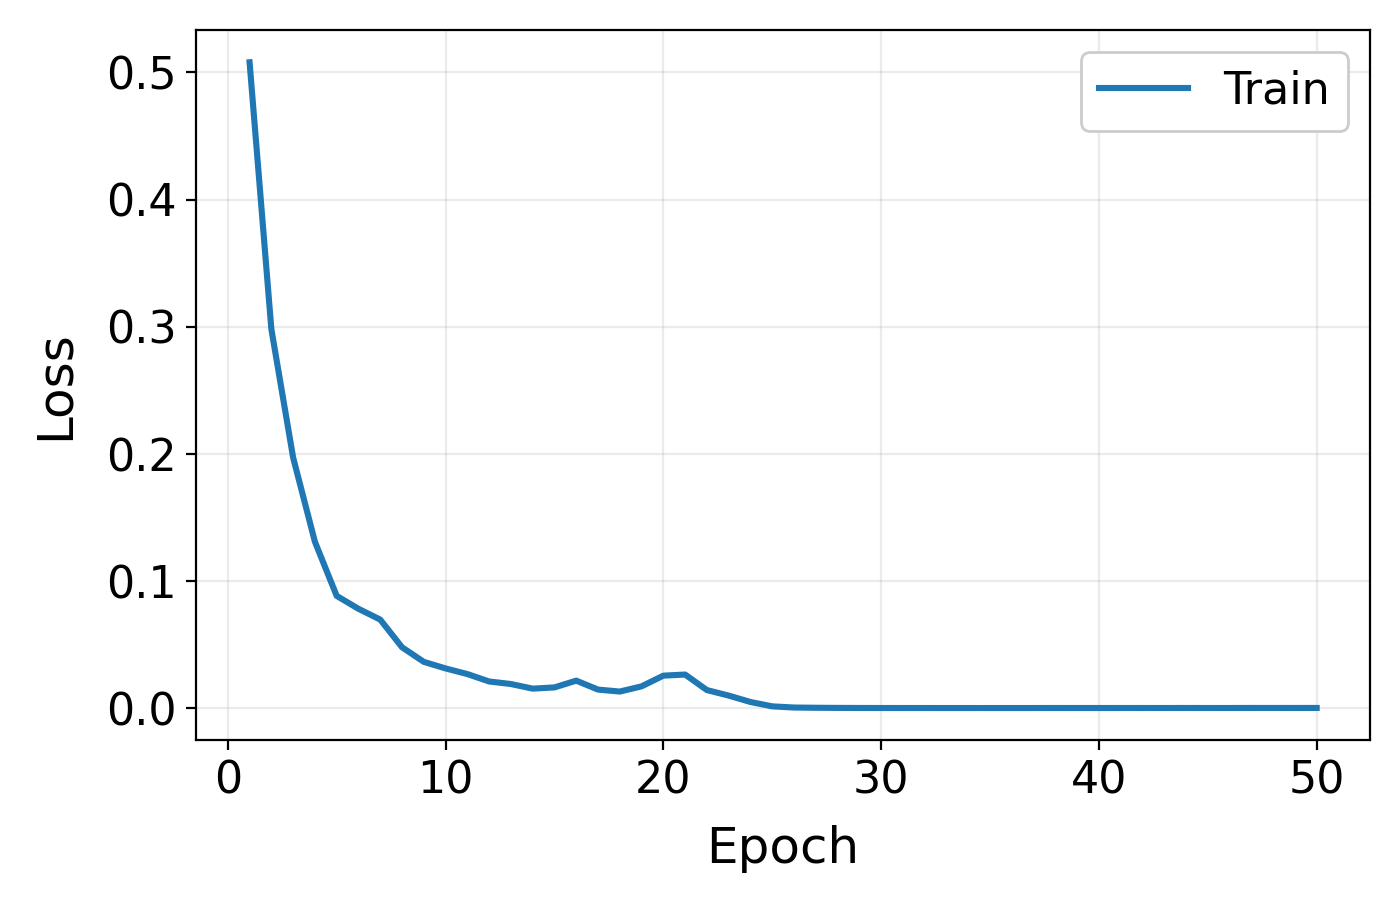

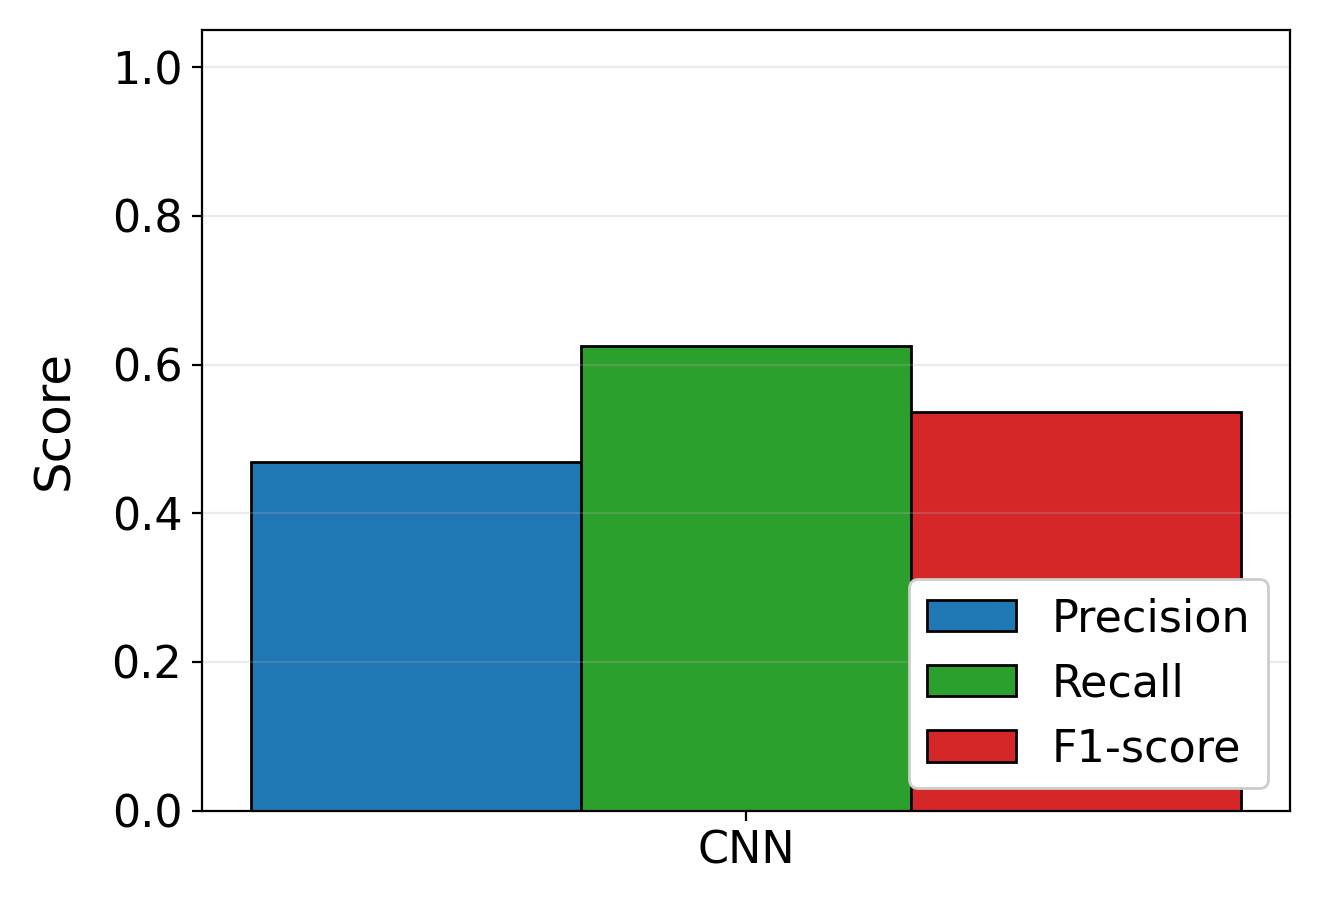

In [35]:
display(Image("outputs/dl/cnn_multiphase/nn_loss_curve.png"))
display(Image("outputs/dl/cnn_multiphase/nn_test-metric_summary.png"))

## 3f) What if we don't account for experimental artifacts?


In [ ]:
from IPython.display import Image, display

from tutorial_utils.runners import run_cnn_no_augmentation


# Same model but now patterns are all idealized
# No strain, texture, broadening, etc.
def cnn_no_augmentation(
    synth_samples_per_formula=60,
    conv_channels=(16, 32),
    kernel_sizes=(27, 15),
    hidden_layer_sizes=(128, 64),
):
    return run_cnn_no_augmentation(
        synth_samples_per_formula=synth_samples_per_formula,
        conv_channels=conv_channels,
        kernel_sizes=kernel_sizes,
        hidden_layer_sizes=hidden_layer_sizes,
        show_steps=False,
        compact_output=True,
    )


In [ ]:
# @title Run CNN (No Augmentation)
cnn_no_augmentation()

Notice the large gap between the model's performance on the validation set (which is purely simulated, idealized patterns) and the test set (which contains experimental measurements).

Without artifacts, the training and validation data is not representative of experiment!

## 3g) What if we add small but random shifts?


In [ ]:
from IPython.display import Image, display

from tutorial_utils.runners import run_cnn_random_shifts


def cnn_random_shifts(
    synth_samples_per_formula=60,
    conv_channels=(16, 32),
    kernel_sizes=(27, 15),
    hidden_layer_sizes=(128, 64),
):
    return run_cnn_random_shifts(
        synth_samples_per_formula=synth_samples_per_formula,
        conv_channels=conv_channels,
        kernel_sizes=kernel_sizes,
        hidden_layer_sizes=hidden_layer_sizes,
        show_steps=False,
        compact_output=True,
    )


In [ ]:
# @title Run CNN (Random Shifts)
cnn_random_shifts()

Once again, this results in very bad performance on experimental data.

It is not enough to randomly perturb the idealized XRD patterns. These perturbations must come from realistic experimental artifacts.

## 3h) Mixture of Experts


In [ ]:
from IPython.display import Image, display
import sys
sys.path.append("..")

from tutorial_utils.runners import run_mixture_of_experts

def create_moe(
    synth_samples_per_formula=60,
    conv_channels=(32, 64),
    kernel_sizes=(27, 15),
    hidden_layer_sizes=(32, 8),
    nn_max_iter=6,
):
    """3h) Mixture-of-experts with architecture controls."""
    return run_mixture_of_experts(
        synth_samples_per_formula=synth_samples_per_formula,
        conv_channels=conv_channels,
        kernel_sizes=kernel_sizes,
        hidden_layer_sizes=hidden_layer_sizes,
        nn_max_iter=nn_max_iter,
        show_steps=False,
        compact_output=True,
    )


Train one lightweight expert per phase label, then combine their outputs.

In [37]:
# @title Run Mixture-of-Experts
create_moe()

# Try on your own:
# 1) Increase number of training patterns.
# create_moe_demo(synth_samples_per_formula=100)
# 2) increase number of model training iterations
# create_moe_demo(nn_max_iter=12)



  Validation P/R/F1: 0.935/0.882/0.908
  Test P/R/F1: 0.531/0.708/0.607 (thr=0.50)
  Saved outputs: outputs\dl\mixture_of_experts


WindowsPath('outputs/dl/mixture_of_experts')

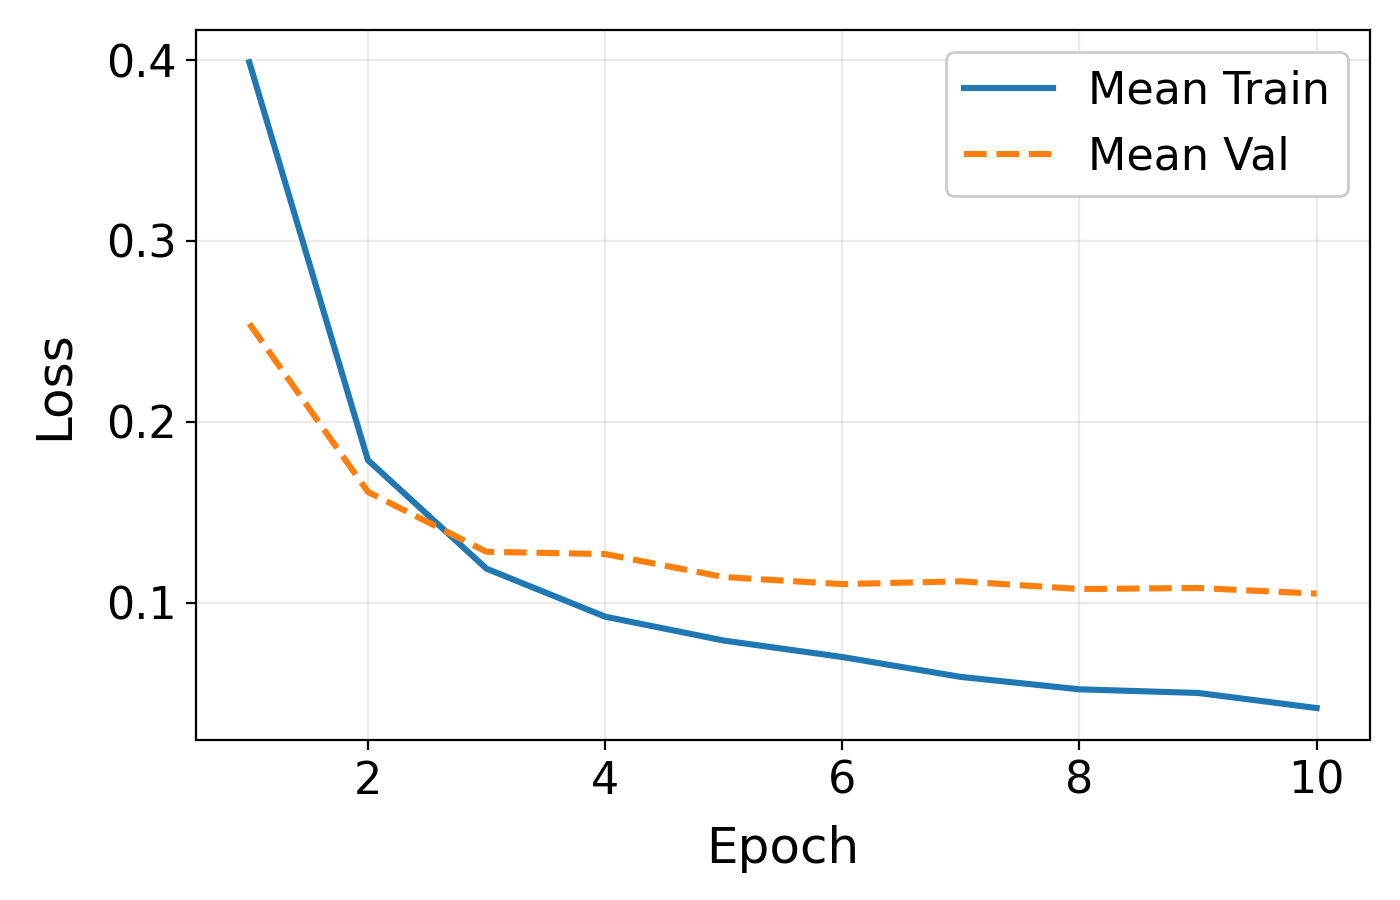

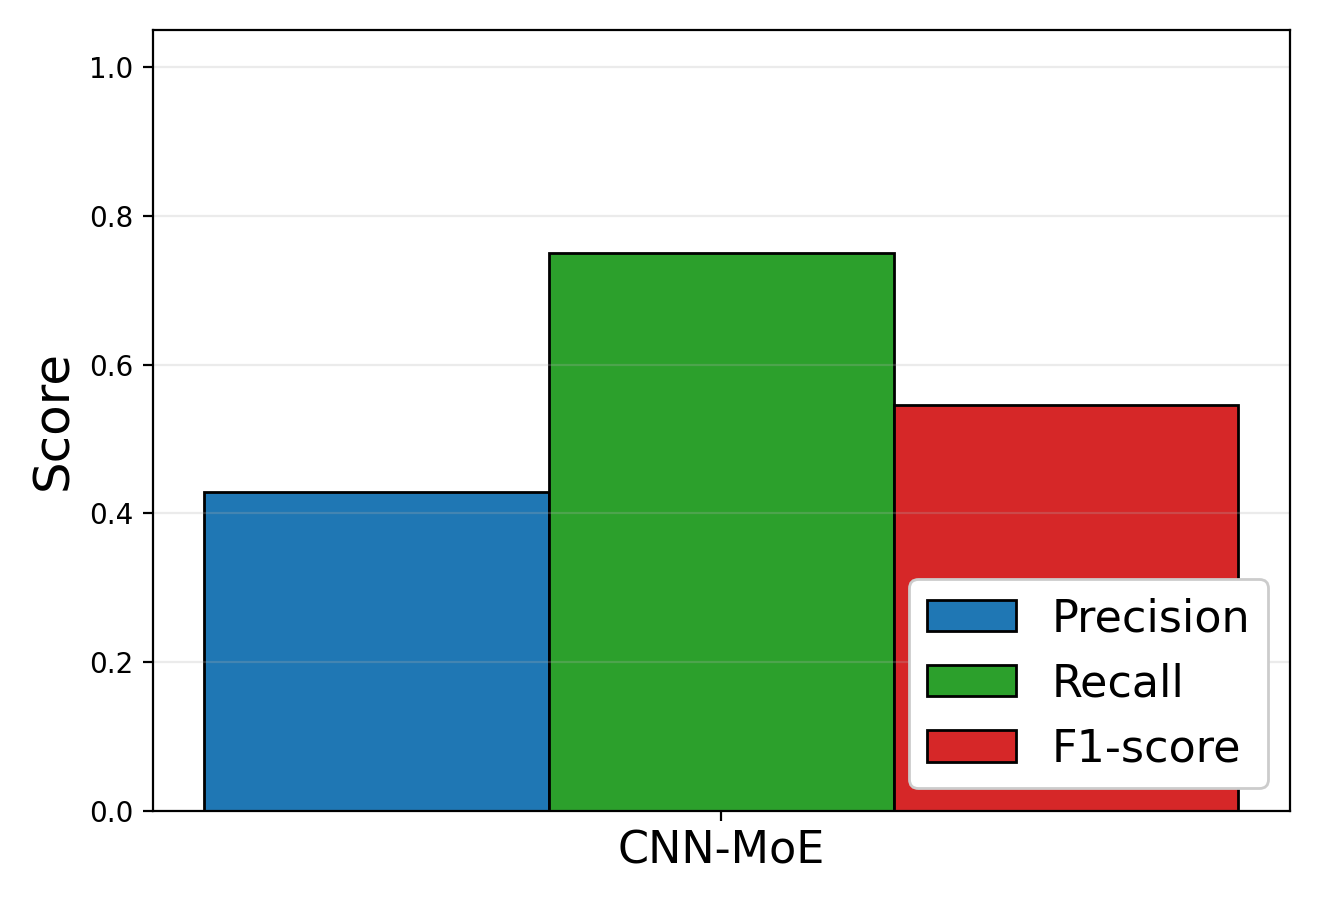

In [9]:
display(Image("outputs/dl/mixture_of_experts/nn_loss_curve.png", width=900))
display(Image("outputs/dl/mixture_of_experts/nn_test-metric_summary.png", width=900))

Notice the improved accuracy and reduced training time.

A mixture of CNN experts is the way to go!